In [1]:
import os
import sys
import pandas as pd
from pathlib import Path
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from utils.dataset.config import DatasetPath
from utils.dataset.clickstream_generator import generate_clickstream

# Dataset Path
- `recsys/data/dataset/` 하위 경로 생성

In [2]:
# 현재 Jupyter Notebook 실행 경로 (e.g., `documents/recsys/2_dataset`)
current_dir = os.path.abspath(os.curdir)

# `../recsys` 경로
base_dir = "/".join(current_dir.split("/")[:-1])

# 데이터셋 경로
dataset_dir = Path(base_dir).joinpath("data/dataset")

paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

# Clickstream Dataset
- 가상의 클릭 스트림 데이터 생성

In [3]:
generate_clickstream(
    user_metadata_path=paths.user_metadata_path,  # 유저 메타데이터 parquet 파일
    item_metadata_path=paths.item_metadata_path,  # 아이템 메타데이터 parquet 파일
    save_path=paths.user_logs_path,  # 생성된 클릭스트림 parquet 파일 저장 경로
    users_per_chunk=1000,  # 유저별 로그를 나누어 저장할 단위 (1000명씩 저장)
    n_sessions_per_user=5,  # 각 유저가 가질 세션 개수
    actions=["click", "wishlist", "cart", "purchase"],  # 행동 유형
    action_weights=[0.8, 0.1, 0.05, 0.05],  # 행동별 확률
    similarity_keys=[
        "gender",
        "age_group",
        "season",
        "master_category",
        "sub_category",
        "article_type",
        "usage",
    ],  # 유사 아이템을 묶을 기준
    start_date=datetime(2025, 9, 1),  # 클릭 로그 시작 시점
    seed=42,  # 랜덤 시드 (재현성)
)

# Load Dataset

In [4]:
df = pd.read_parquet(paths.user_logs_path)

In [5]:
df.shape

(218512, 21)

In [6]:
df.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,4407,2025-09-21 03:01:00,click,46,Men,French Connection Men Black Trousers,French Connection,3699.0,3699.0,...,Black,Summer,2012,Formal,Apparel,Bottomwear,Trousers,<UNK>,Formal,<p><strong>Style Note</strong><br />These form...
1,1,3951,2025-09-21 03:02:00,click,46,Men,John Miller Men Black Trousers,John Miller,1099.0,1099.0,...,Black,Summer,2012,Formal,Apparel,Bottomwear,Trousers,<UNK>,<UNK>,<p><strong>Composition</strong><br /> Black fo...
2,1,2209,2025-09-21 03:05:00,click,46,Men,Genesis Men Black Trousers,Genesis,1499.0,1499.0,...,Black,Summer,2012,Formal,Apparel,Bottomwear,Trousers,Slim Fit,<UNK>,<p><strong>Composition</strong><br /> Black fo...
3,1,1759,2025-09-21 03:04:00,click,46,Men,Mark Taylor Men Striped Black Trousers,Mark Taylor,779.0,779.0,...,Black,Summer,2012,Formal,Apparel,Bottomwear,Trousers,<UNK>,<UNK>,<p><strong>Composition</strong><br />Black tro...
4,1,8657,2025-09-21 03:17:00,click,46,Men,Arrow Men Black Trousers,Arrow,1799.0,1799.0,...,Black,Summer,2013,Formal,Apparel,Bottomwear,Trousers,Slim Fit,<UNK>,<p><strong>Composition</strong><br /> Black fl...


# EDA

## Item Frequency

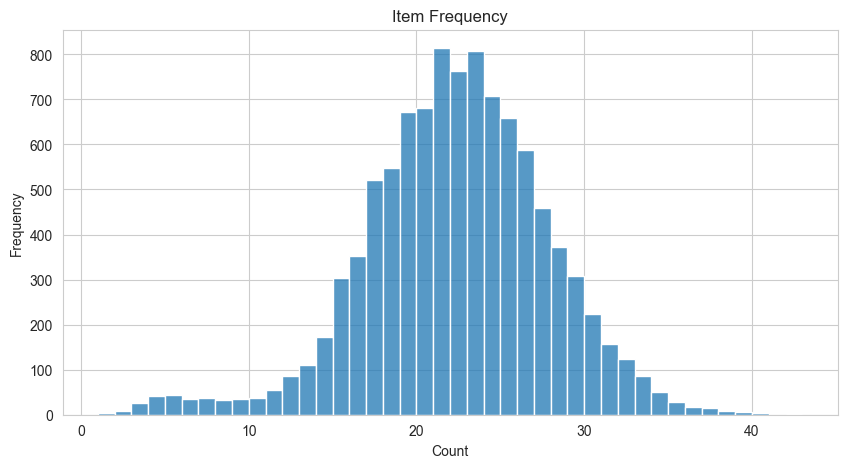

In [7]:
# - `item_id`별 등장 횟수를 세어 분포 확인
# - 인기 아이템과 Long-tail 아이템을 직관적으로 볼 수 있음
plt.figure(figsize=(10, 5), dpi=100)
sns.histplot(x=df["item_id"].value_counts(), binwidth=1)
plt.title("Item Frequency")
plt.xlabel("Count")  # 특정 아이템이 등장한 횟수
plt.ylabel("Frequency")  # 등장 횟수별 아이템의 개수
plt.show()